# 📊 Phase 1: 서울시 25개 구 중 최적 지역구 선정

---

**목적**: 편의점 입지에 유리한 지역구를 데이터 기반으로 선별  
**방법**: 8개 변수 Min-Max 정규화 → 종합점수 산출 → 폐업률 교차검증  
**결과**: 관악구 선정

**사용 데이터**: 안전상비의약품 판매업소 인허가 정보, 서울시 행정구역 SHP, 유입·유출 인구 데이터

## 1. 24시간 편의점 필터링

24시간 편의점은 안전상비의약품 판매 인허가를 받아야 하므로,  
이 데이터를 통해 24시간 운영 편의점을 식별합니다.

In [1]:
import pandas as pd
import numpy as np

In [24]:
df=pd.read_csv('서울시 안전상비의약품 판매업소 인허가 정보.csv',encoding='cp949')


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17205 entries, 0 to 17204
Data columns (total 26 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   개방자치단체코드  17205 non-null  int64  
 1   관리번호      17205 non-null  object 
 2   인허가일자     17205 non-null  object 
 3   인허가취소일자   343 non-null    object 
 4   영업상태코드    17205 non-null  int64  
 5   영업상태명     17205 non-null  object 
 6   상세영업상태코드  17205 non-null  int64  
 7   상세영업상태명   17205 non-null  object 
 8   폐업일자      10021 non-null  object 
 9   휴업시작일자    12 non-null     object 
 10  휴업종료일자    11 non-null     object 
 11  재개업일자     0 non-null      float64
 12  전화번호      6992 non-null   object 
 13  소재지면적     0 non-null      float64
 14  소재지우편번호   5686 non-null   object 
 15  지번주소      15003 non-null  object 
 16  도로명주소     17184 non-null  object 
 17  도로명우편번호   17176 non-null  object 
 18  사업장명      17205 non-null  object 
 19  최종수정일자    17205 non-null  object 
 20  데이터갱신구분   17205 non-null  ob

In [28]:
df=df[df['영업상태명'] =='영업/정상']

In [30]:
df1=df[['영업상태코드','영업상태명','상세영업상태코드','상세영업상태명','도로명주소','도로명우편번호','사업장명','좌표정보(X)','좌표정보(Y)']]
df1

,영업상태코드,영업상태명,상세영업상태코드,상세영업상태명,도로명주소,도로명우편번호,사업장명,좌표정보(X),좌표정보(Y)
3,1,영업/정상,13,영업중,"서울특별시 광진구 용마산로 183, 101호 (중곡동)",04903,이마트24중곡용마로점,207517.232683,451973.410322
4,1,영업/정상,13,영업중,"서울특별시 동대문구 장한로26가길 81, 1층 (장안동)",02639,이마트24 장안라보니타점,206136.412125,451780.560755
7,1,영업/정상,13,영업중,"서울특별시 광진구 천호대로127길 13, 1층 (중곡동)",04953,지에스25 아차산본점,207849.231389,450167.497715
8,1,영업/정상,13,영업중,"서울특별시 동대문구 서울시립대로 19, 1층 101호 (답십리동, 청계와이즈노벨리아...",02592,서울동대문지역자활센터 씨유청계노벨리아,203909.292627,452395.684362
9,1,영업/정상,13,영업중,"서울특별시 중랑구 겸재로50길 52, 1층 (면목동)",02202,지에스(GS)25면목겸재,208167.021532,454062.858607
...,...,...,...,...,...,...,...,...,...
17198,1,영업/정상,13,영업중,"서울특별시 서초구 서초대로 355, 서초메이플라워맴버스빌 1층 101호 (서초동)",06607,세븐일레븐서초메이플점,201711.438277,443758.656720
17199,1,영업/정상,13,영업중,"서울특별시 마포구 양화로6길 67, 1층 101호 (서교동)",04047,(주)지에스25합정태양점,192683.268761,449608.324922
17200,1,영업/정상,13,영업중,"서울특별시 구로구 경인로33길 76, 1층 (고척동)",08234,씨유 개봉리치점,186747.629914,444364.318947
17201,1,영업/정상,13,영업중,"서울특별시 광진구 용마산로 86, 무니빌딩 1층 (중곡동)",04942,씨유 중곡무니점,207669.123938,450999.743703


In [32]:
df1.isnull().sum()

영업상태코드       0
영업상태명        0
상세영업상태코드     0
상세영업상태명      0
도로명주소        0
도로명우편번호      1
사업장명         0
좌표정보(X)     90
좌표정보(Y)     90
dtype: int64

## 2. 좌표 변환 (EPSG:2097 → EPSG:4326)

원본 좌표계(중부원점 TM)를 GPS 좌표계(WGS84)로 변환합니다.

In [36]:
from pyproj import Transformer
import pandas as pd

transformer = Transformer.from_crs("EPSG:2097", "EPSG:4326", always_xy=True)

In [38]:
df1['위도'],df1['경도']= transformer.transform(df1['좌표정보(X)'].values,df1['좌표정보(Y)'].values)

C:\Users\82104\AppData\Local\Temp\ipykernel_18104\2151049788.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['위도'],df1['경도']= transformer.transform(df1['좌표정보(X)'].values,df1['좌표정보(Y)'].values)
C:\Users\82104\AppData\Local\Temp\ipykernel_18104\2151049788.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['위도'],df1['경도']= transformer.transform(df1['좌표정보(X)'].values,df1['좌표정보(Y)'].values)


In [40]:
df1=df1.drop(['좌표정보(X)','좌표정보(Y)'],axis=1)

In [42]:
df1

,영업상태코드,영업상태명,상세영업상태코드,상세영업상태명,도로명주소,도로명우편번호,사업장명,위도,경도
3,1,영업/정상,13,영업중,"서울특별시 광진구 용마산로 183, 101호 (중곡동)",04903,이마트24중곡용마로점,127.082989,37.570018
4,1,영업/정상,13,영업중,"서울특별시 동대문구 장한로26가길 81, 1층 (장안동)",02639,이마트24 장안라보니타점,127.067357,37.568291
7,1,영업/정상,13,영업중,"서울특별시 광진구 천호대로127길 13, 1층 (중곡동)",04953,지에스25 아차산본점,127.086728,37.553744
8,1,영업/정상,13,영업중,"서울특별시 동대문구 서울시립대로 19, 1층 101호 (답십리동, 청계와이즈노벨리아...",02592,서울동대문지역자활센터 씨유청계노벨리아,127.042151,37.573845
9,1,영업/정상,13,영업중,"서울특별시 중랑구 겸재로50길 52, 1층 (면목동)",02202,지에스(GS)25면목겸재,127.090367,37.588838
...,...,...,...,...,...,...,...,...,...
17198,1,영업/정상,13,영업중,"서울특별시 서초구 서초대로 355, 서초메이플라워맴버스빌 1층 101호 (서초동)",06607,세븐일레븐서초메이플점,127.017252,37.496032
17199,1,영업/정상,13,영업중,"서울특별시 마포구 양화로6길 67, 1층 101호 (서교동)",04047,(주)지에스25합정태양점,126.915100,37.548709
17200,1,영업/정상,13,영업중,"서울특별시 구로구 경인로33길 76, 1층 (고척동)",08234,씨유 개봉리치점,126.848026,37.501395
17201,1,영업/정상,13,영업중,"서울특별시 광진구 용마산로 86, 무니빌딩 1층 (중곡동)",04942,씨유 중곡무니점,127.084698,37.561244


## 3. 서울시 행정구역 SHP 파일과 공간결합

편의점 좌표를 서울시 행정구역 경계와 공간결합(Spatial Join)하여  
각 편의점이 어느 구에 속하는지 매핑합니다.

In [44]:
import geopandas as gpd
서울시맵 = gpd.read_file('LARD_ADM_SECT_SGG_11_202405.shp')

In [46]:
# GRS80 좌표계로 설정 (EPSG:5186)
if 서울시맵.crs is None:
    서울시맵 = 서울시맵.set_crs("EPSG:5186")

# WGS84로 변환
서울시맵 = 서울시맵.to_crs("EPSG:4326")
print("변환 후 좌표계:", 서울시맵.crs)

변환 후 좌표계: EPSG:4326


C:\Users\82104\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\anaconda

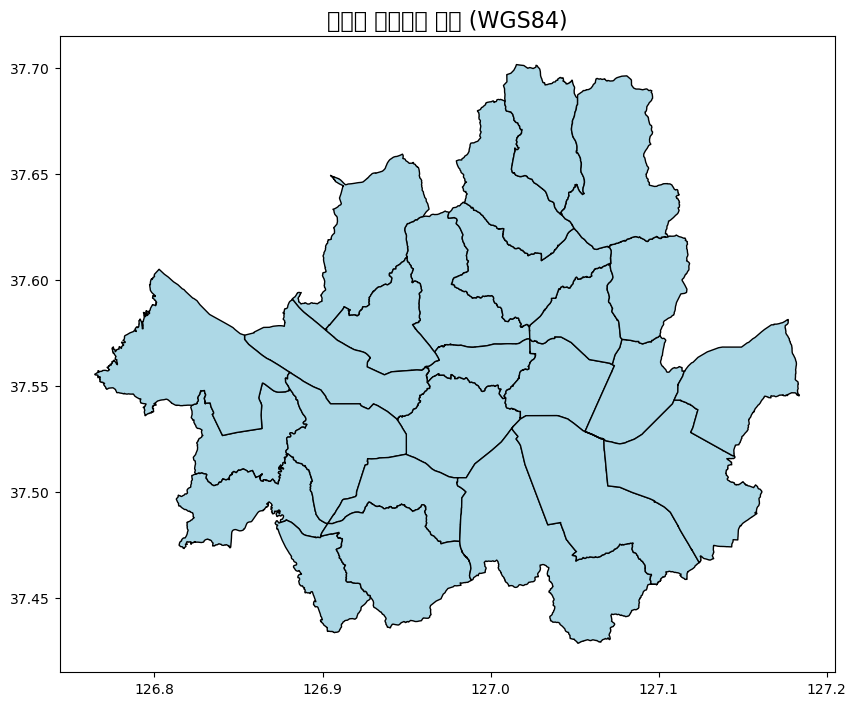

In [48]:
import matplotlib.pyplot as plt
서울시맵.plot(figsize=(10, 10), color='lightblue', edgecolor='black')
plt.title("서울시 행정구역 지도 (WGS84)", fontsize=16)
plt.show()

In [50]:
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(df1['위도'], df1['경도'])]
store_locations = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326") 

C:\Users\82104\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54200 (\N{HANGUL SYLLABLE PYEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\anaconda3\L

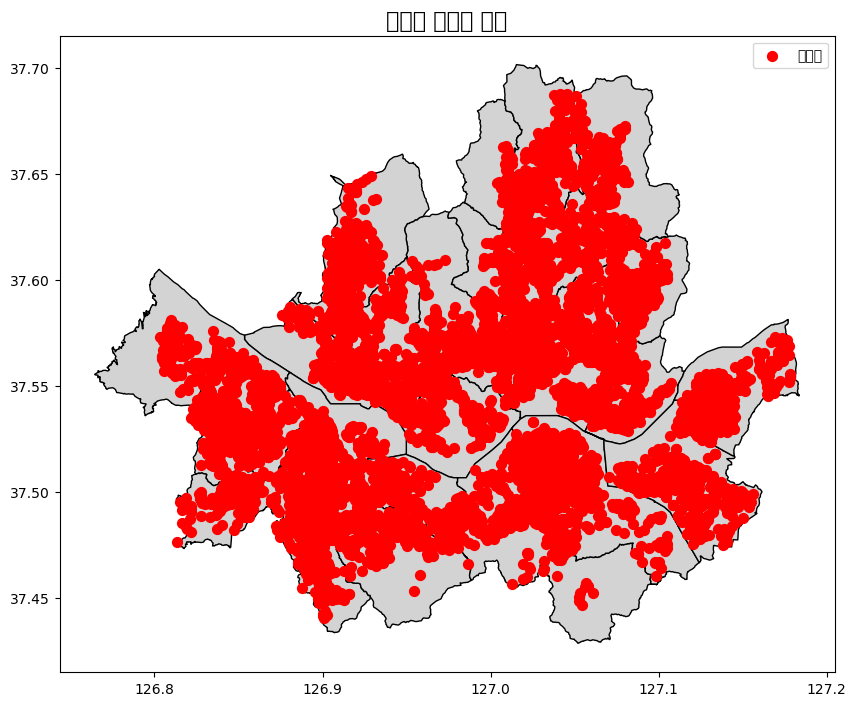

In [52]:
import matplotlib.pyplot as plt

# 지도 그리기
fig, ax = plt.subplots(figsize=(10, 10))

# SHAP 파일 지도
서울시맵.plot(ax=ax, color='lightgrey', edgecolor='black')  # 행정구역 경계

# 편의점 데이터
store_locations.plot(ax=ax, color='red', markersize=50, label='편의점')

# 제목 및 범례 추가
plt.title("서울시 편의점 분포", fontsize=16)
plt.legend()
plt.show()

In [54]:
plt.rcParams['font.family'] = 'Malgun Gothic'  
plt.rcParams['axes.unicode_minus'] = False

In [56]:
merged = gpd.sjoin(store_locations, 서울시맵, how='left', predicate='intersects')

In [58]:
store_count_by_district = merged.groupby('SGG_NM').size().reset_index(name='store_count')

## 4. 구별 편의점 분포 시각화 및 밀집도 계산

C:\Users\82104\AppData\Local\Temp\ipykernel_18104\1407301793.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, name, count in zip(서울시맵.geometry.centroid.x,
C:\Users\82104\AppData\Local\Temp\ipykernel_18104\1407301793.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  서울시맵.geometry.centroid.y,


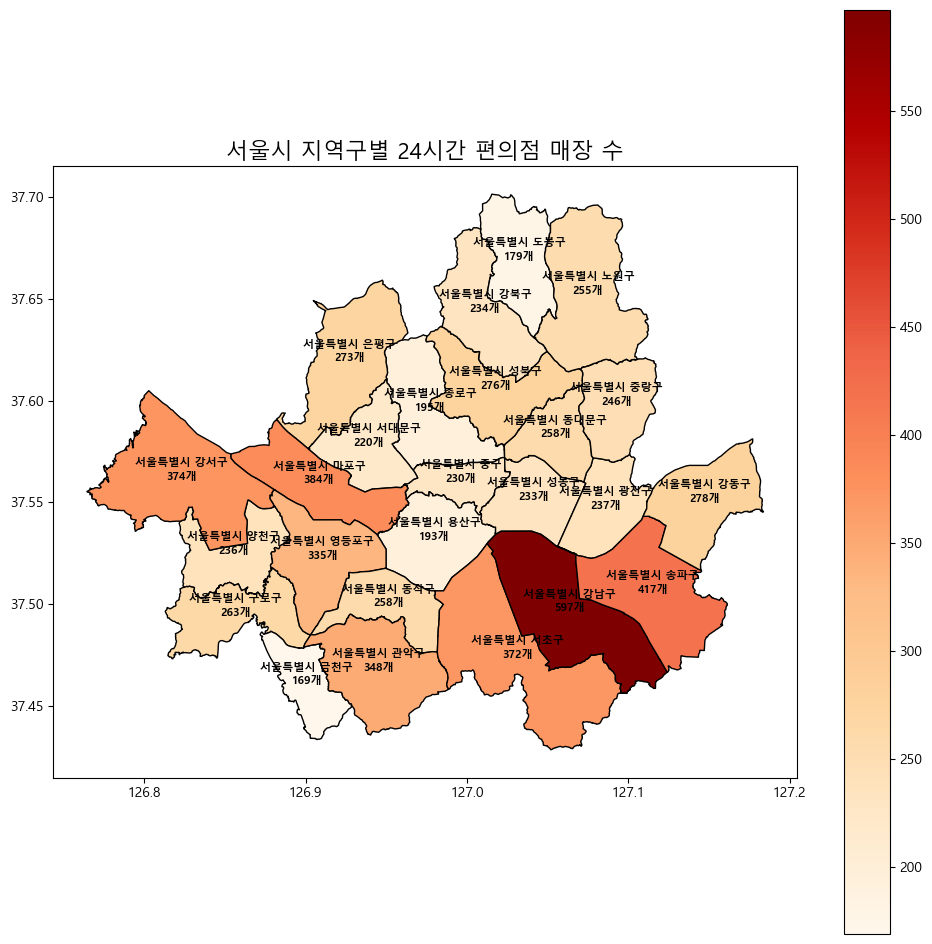

In [62]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 지역구 지도 위에 매장 수와 이름 표시
fig, ax = plt.subplots(figsize=(12, 12))

# 지역구별 매장 수를 색상으로 표시
서울시맵.plot(column='store_count', ax=ax, cmap='OrRd', legend=True, edgecolor='black')

# 지역구 이름과 매장 수를 텍스트로 표시
for x, y, name, count in zip(서울시맵.geometry.centroid.x, 
                             서울시맵.geometry.centroid.y, 
                             서울시맵['SGG_NM'], 
                             서울시맵['store_count']):
    # 텍스트 출력 (지역구 이름과 매장 수)
    plt.text(x, y, f"{name}\n{count}개", fontsize=8, ha='center', color='black', fontweight='bold')

# 제목 추가
plt.title("서울시 지역구별 24시간 편의점 매장 수", fontsize=16)
plt.show()

In [64]:
서울시맵['SGG_NM']=서울시맵['SGG_NM'].str.replace('서울특별시','').str.strip()

In [66]:
서울시점포수=서울시맵[['SGG_NM', 'store_count']].sort_values(by='store_count', ascending=False)
서울시점포수.tail(10)

,SGG_NM,store_count
4,광진구,237
14,양천구,236
8,강북구,234
3,성동구,233
1,중구,230
12,서대문구,220
0,종로구,195
2,용산구,193
9,도봉구,179
17,금천구,169


## 5. 면적 대비 편의점 밀집도 계산

In [68]:
data = {
    "Rank": list(range(1, 26)),
    "SGG_NM": [
        "서초구", "강서구", "강남구", "노원구", "송파구", "은평구", "관악구", "강동구", "성북구",
        "영등포구", "종로구", "마포구", "강북구", "용산구", "도봉구", "구로구", "중랑구", "서대문구",
        "양천구", "광진구", "성동구", "동작구", "동대문구", "금천구", "중구"
    ],
    "지역구면적": [
        46.98, 41.44, 39.50, 35.44, 33.87, 29.71, 29.57, 24.59, 24.58, 24.55, 
        23.91, 23.85, 23.60, 21.87, 20.65, 20.12, 18.50, 17.63, 17.41, 17.06, 
        16.86, 16.35, 14.22, 13.02, 9.96
    ]
}

# Create the DataFrame
지역구= pd.DataFrame(data)

In [70]:
지역구면적밀집도=pd.merge(서울시점포수,지역구,on='SGG_NM')

In [72]:
지역구면적밀집도['면적대비_밀집도']=지역구면적밀집도['store_count']/지역구면적밀집도['지역구면적']

In [74]:
지역구면적밀집도.sort_values(by='면적대비_밀집도')

,SGG_NM,store_count,Rank,지역구면적,면적대비_밀집도
13,노원구,255,4,35.44,7.195260
4,서초구,372,1,46.98,7.918263
21,종로구,195,11,23.91,8.155583
23,도봉구,179,15,20.65,8.668281
22,용산구,193,14,21.87,8.824874
3,강서구,374,2,41.44,9.025097
9,은평구,273,6,29.71,9.188825
17,강북구,234,13,23.60,9.915254
8,성북구,276,9,24.58,11.228641
7,강동구,278,8,24.59,11.305409


In [78]:
지역구면적밀집도.sort_values(by='면적대비_밀집도').head(10)

,SGG_NM,편의점수,면적순위,지역구면적,면적대비_밀집도
13,노원구,255,4,35.44,7.195260
4,서초구,372,1,46.98,7.918263
21,종로구,195,11,23.91,8.155583
23,도봉구,179,15,20.65,8.668281
22,용산구,193,14,21.87,8.824874
3,강서구,374,2,41.44,9.025097
9,은평구,273,6,29.71,9.188825
17,강북구,234,13,23.60,9.915254
8,성북구,276,9,24.58,11.228641
7,강동구,278,8,24.59,11.305409


## 6. 밀집도 지도 시각화

C:\Users\82104\AppData\Local\Temp\ipykernel_18104\3883965643.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, name, count in zip(서울시맵.geometry.centroid.x,
C:\Users\82104\AppData\Local\Temp\ipykernel_18104\3883965643.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  서울시맵.geometry.centroid.y,


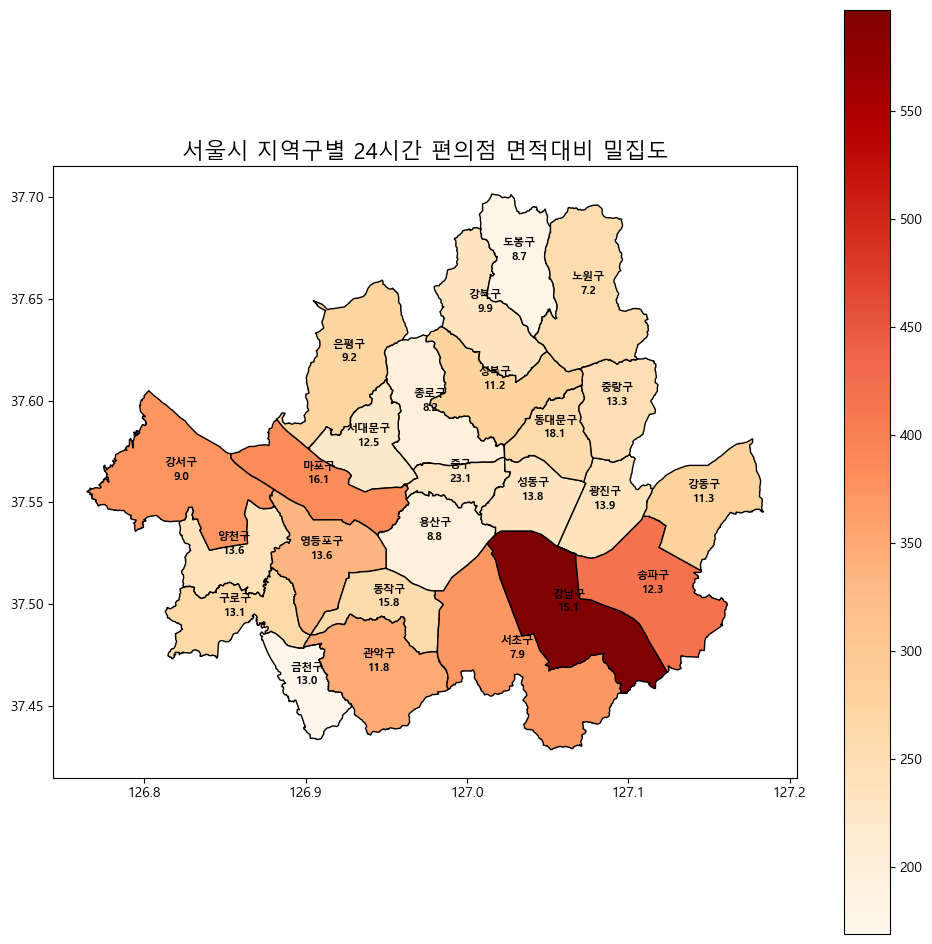

In [86]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 지역구 지도 위에 매장 수와 이름 표시
fig, ax = plt.subplots(figsize=(12, 12))

# 지역구별 매장 수를 색상으로 표시
서울시맵.plot(column='store_count', ax=ax, cmap='OrRd', legend=True, edgecolor='black')

# 지역구 이름과 매장 수를 텍스트로 표시
for x, y, name, count in zip(서울시맵.geometry.centroid.x, 
                             서울시맵.geometry.centroid.y, 
                             서울시맵['SGG_NM'], 
                             서울시맵['면적대비_밀집도']):
    # 텍스트 출력 (지역구 이름과 매장 수)
    plt.text(x, y, f"{name}\n{count}", fontsize=8, ha='center', color='black', fontweight='bold')

# 제목 추가
plt.title("서울시 지역구별 24시간 편의점 면적대비 밀집도", fontsize=16)
plt.show()

## 7. 결론: 관악구 선정

이 총인구,밀집도,편의점수, 지역구 월별 맥주판매량 등등의 조건을 종합하여 점수를 계산한 결과
** 자세한 사항은 엑셀파일 참조**

**종합점수 상위 3개 구**: 양천구(3.81), 관악구(3.80), 송파구(3.39) 

10년간 폐업률을 교차 검증한 결과, **폐업률이 가장 낮은 관악구**를 최종 선정했습니다.
> 💡 양천구가 종합점수 1위였지만, 폐업률 교차검증을 통해  
> 지속가능성까지 고려하여 관악구를 선정했습니다.